In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum, OpenSimPendulum  
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config              

In [10]:
master = FEMPendulum("Master")
master.initialize(0.0)
master._use_gravity = True
master._with_contact = True

model = OpenSimPendulum()
model._use_gravity = master._use_gravity
model._with_contact = master._with_contact

total_inertia = master.inertia
mass = master.mass
length = master._equivalent_length
inertia = total_inertia - mass * (length**2)

model.parameters["Model"]["inertia"] = inertia
model.parameters["Model"]["mass"] = mass
model.parameters["Model"]["length"] = length

model.parameters["InitialConditions"]["theta_start"] = np.deg2rad(10)
model.parameters["InitialConditions"]["omega0"] = 0
model.parameters["InitialConditions"]["torque0"] = 1

model.initialize(0.0)

In [12]:
model.parameters["Contact"]["stiffness"] = 1e12
model.parameters["Contact"]["dissipation"] = 0
model.parameters["Contact"]["static_friction"] = 0
model.parameters["Contact"]["dynamic_friction"] = 0
model.parameters["Contact"]["viscous_friction"] = 0

In [13]:
model.initialize(0.0)

In [14]:
t_end = master.sim_params.t_end
dt = master.sim_params.tau
t = 0.0

while t < t_end:
    # 1) Integrate one time step
    model.do_step(t, dt)

    # 2) Advance time
    t += dt

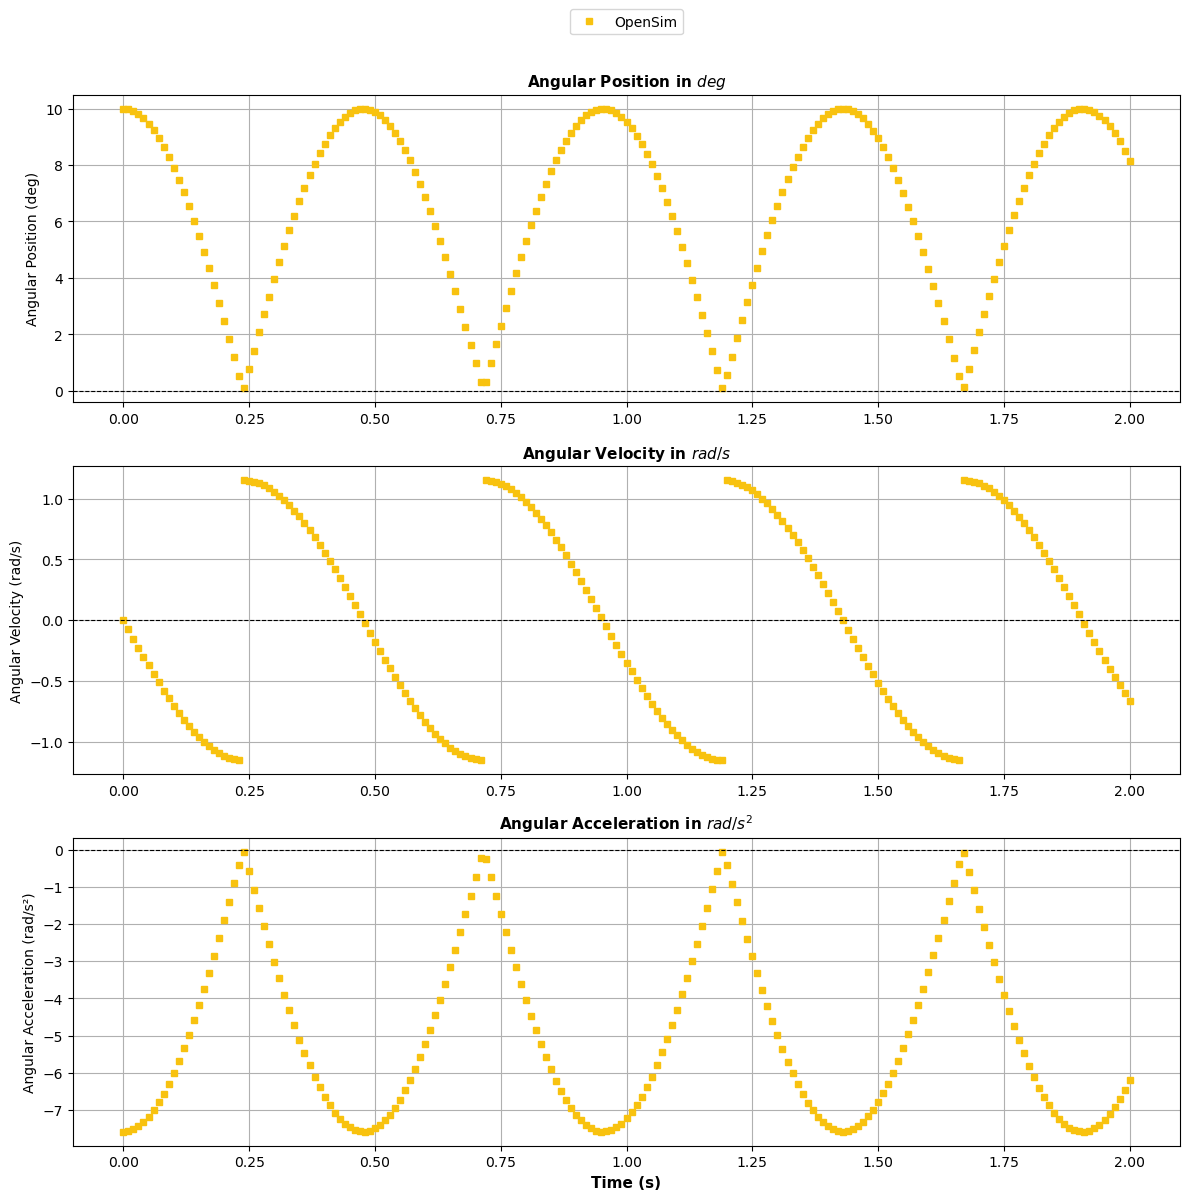

In [15]:
results = model.get_history()

time = results["theta"]["time"]
theta = results["theta"]["values"]
omega = results["omega"]["values"]
alpha = results["alpha"]["values"]

marker_size = 4
fem_style = {
    "color": "#12e2d1",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
fmu = {
    "color": "#1d8d43",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(time, np.rad2deg(theta), label="OpenSim", **opensim_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which="both")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3, 1, 2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(time, omega, label="OpenSim", **opensim_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(time, alpha, label="OpenSim", **opensim_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which="both")

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
# plt.savefig("../figures/StateSynchronization_driven.svg")
plt.show()